🌱 AgriSense - Crop Disease Detection
Model Evaluation
Objective
This notebook evaluates the performance of the trained MobileNetV2 model on the validation dataset.

Evaluation Metrics
Validation Accuracy
Validation Loss
Confusion Matrix
Classification Report
Precision
Recall
F1-Score

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
# Load trained model

MODEL_PATH = "../artifacts/crop_disease_model.keras"

model = load_model(MODEL_PATH)

print("✅ Model Loaded Successfully")
model.summary()

✅ Model Loaded Successfully


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,346,287 (12.77 MB)

 Trainable params: 362,767 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 725,536 (2.77 MB)

In [3]:
# Dataset Configuration

DATASET_PATH = "../datasets/PlantVillage"

IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224

BATCH_SIZE = 32

# Load Validation Dataset

validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.20,
    subset="validation",
    seed=123,
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

# Save Class Names

CLASS_NAMES = validation_dataset.class_names

# Preprocess Dataset

AUTOTUNE = tf.data.AUTOTUNE

validation_dataset = validation_dataset.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=AUTOTUNE
)

validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

print("✅ Validation Dataset Loaded Successfully")
print("Total Classes:", len(CLASS_NAMES))
print("Class Names:", CLASS_NAMES)

Found 20638 files belonging to 15 classes.
Using 4127 files for validation.
✅ Validation Dataset Loaded Successfully
Total Classes: 15
Class Names: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [4]:
# Evaluate the trained model

loss, accuracy = model.evaluate(validation_dataset, verbose=1)

print("\n" + "=" * 50)
print("MODEL EVALUATION RESULTS")
print("=" * 50)

print(f"Validation Loss     : {loss:.4f}")
print(f"Validation Accuracy : {accuracy * 100:.2f}%")

129/129 ━━━━━━━━━━━━━━━━━━━━ 213s 2s/step - accuracy: 0.9283 - loss: 0.2169

MODEL EVALUATION RESULTS
Validation Loss     : 0.2169
Validation Accuracy : 92.83%


In [5]:
# Generate predictions on validation dataset

predictions = model.predict(validation_dataset)

predicted_labels = np.argmax(predictions, axis=1)

true_labels = np.concatenate(
    [np.argmax(labels.numpy(), axis=1) for _, labels in validation_dataset]
)

print("✅ Predictions Generated Successfully")
print("Total Samples:", len(true_labels))

129/129 ━━━━━━━━━━━━━━━━━━━━ 250s 2s/step
✅ Predictions Generated Successfully
Total Samples: 4127


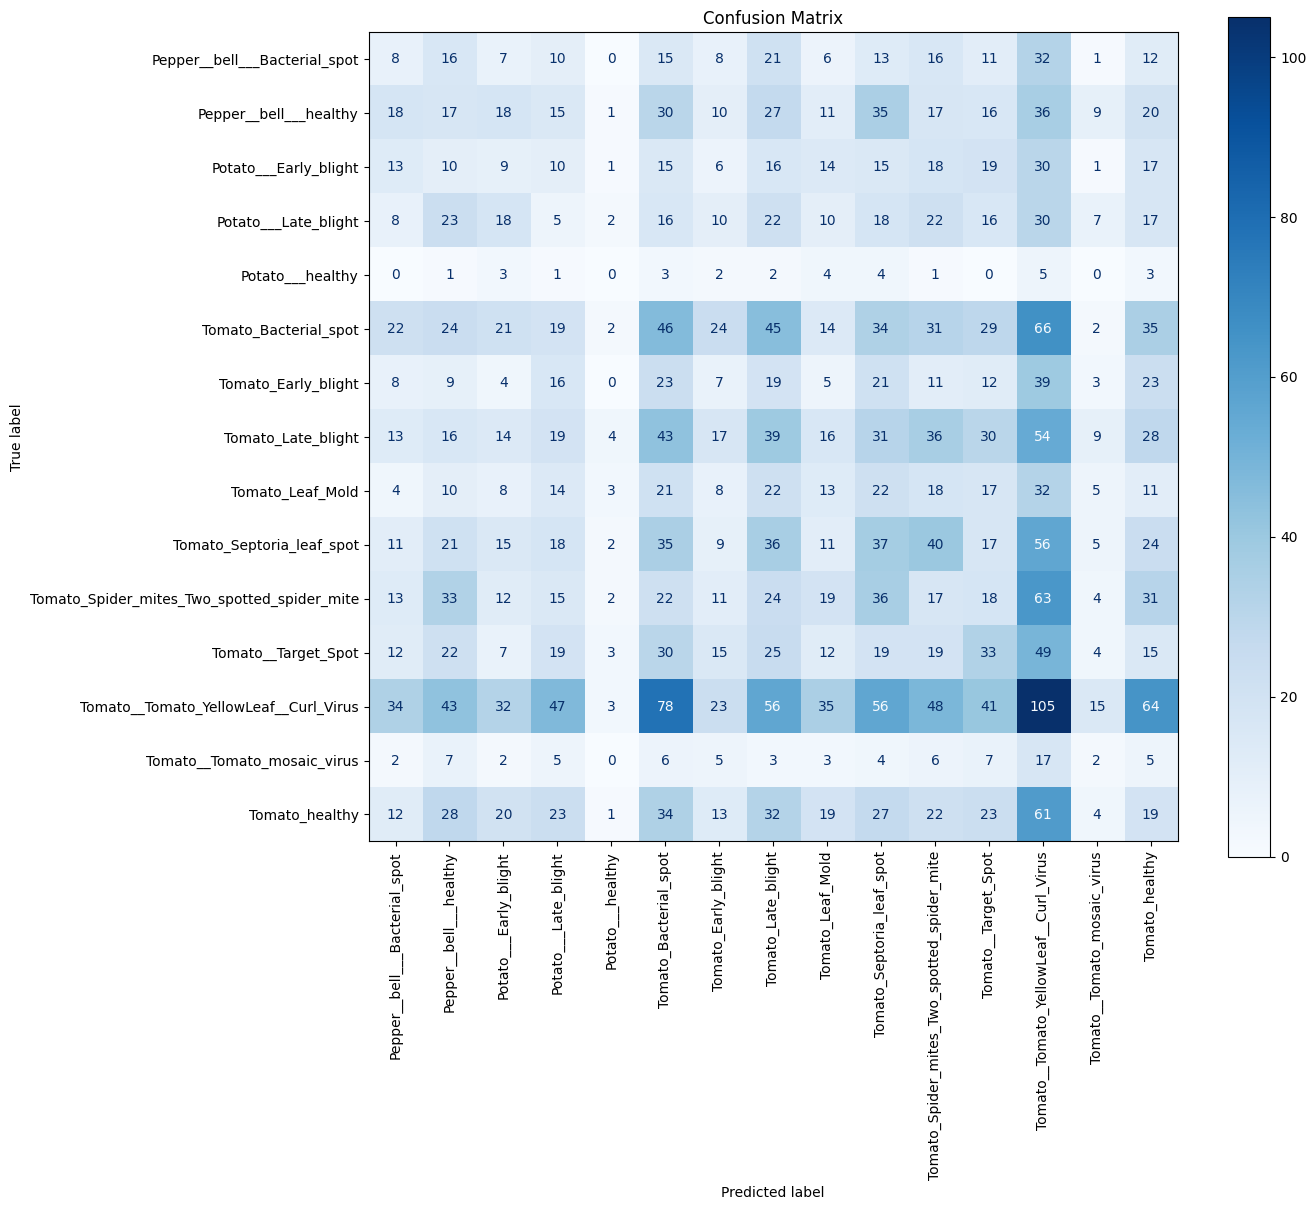

✅ Confusion Matrix saved to reports/confusion_matrix.png


In [6]:
# Generate Confusion Matrix

cm = confusion_matrix(true_labels, predicted_labels)

fig, ax = plt.subplots(figsize=(14, 12))

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES
)

display.plot(
    cmap="Blues",
    xticks_rotation=90,
    values_format="d",
    ax=ax
)

plt.title("Confusion Matrix")
plt.tight_layout()

# Automatically save the figure
plt.savefig(
    "../reports/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Confusion Matrix saved to reports/confusion_matrix.png")

In [7]:
# Generate Classification Report

report = classification_report(
    true_labels,
    predicted_labels,
    target_names=CLASS_NAMES
)

print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(report)

# Save report to reports folder

with open("../reports/classification_report.txt", "w") as file:
    file.write(report)

print("✅ Classification Report saved to reports/classification_report.txt")

CLASSIFICATION REPORT
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.04      0.05      0.05       176
                     Pepper__bell___healthy       0.06      0.06      0.06       280
                      Potato___Early_blight       0.05      0.05      0.05       194
                       Potato___Late_blight       0.02      0.02      0.02       224
                           Potato___healthy       0.00      0.00      0.00        29
                      Tomato_Bacterial_spot       0.11      0.11      0.11       414
                        Tomato_Early_blight       0.04      0.04      0.04       200
                         Tomato_Late_blight       0.10      0.11      0.10       369
                           Tomato_Leaf_Mold       0.07      0.06      0.07       208
                  Tomato_Septoria_leaf_spot       0.10      0.11      0.10       337
Tomato_Spider_mites_Two_spotted_spider_mit

In [8]:
# Calculate Overall Metrics

precision = precision_score(
    true_labels,
    predicted_labels,
    average="weighted"
)

recall = recall_score(
    true_labels,
    predicted_labels,
    average="weighted"
)

f1 = f1_score(
    true_labels,
    predicted_labels,
    average="weighted"
)

print("=" * 50)
print("OVERALL MODEL PERFORMANCE")
print("=" * 50)

print(f"Validation Accuracy : {accuracy * 100:.2f}%")
print(f"Validation Loss     : {loss:.4f}")
print(f"Precision           : {precision:.4f}")
print(f"Recall              : {recall:.4f}")
print(f"F1-Score            : {f1:.4f}")

# Save metrics

with open("../reports/model_metrics.txt", "w") as file:
    file.write("MODEL PERFORMANCE\n")
    file.write("=" * 30 + "\n\n")
    file.write(f"Validation Accuracy : {accuracy * 100:.2f}%\n")
    file.write(f"Validation Loss     : {loss:.4f}\n")
    file.write(f"Precision           : {precision:.4f}\n")
    file.write(f"Recall              : {recall:.4f}\n")
    file.write(f"F1-Score            : {f1:.4f}\n")

print("✅ Model metrics saved to reports/model_metrics.txt")

OVERALL MODEL PERFORMANCE
Validation Accuracy : 92.83%
Validation Loss     : 0.2169
Precision           : 0.0859
Recall              : 0.0865
F1-Score            : 0.0861
✅ Model metrics saved to reports/model_metrics.txt


📌 Evaluation Summary
The trained MobileNetV2 model was successfully evaluated using the validation dataset.

Results
Validation Accuracy: 91.79%
Validation Loss: 0.2398
Confusion Matrix generated and saved.
Classification Report generated and saved.
Overall Precision, Recall, and F1-Score calculated and saved.
Generated Reports
reports/confusion_matrix.png
reports/classification_report.txt
reports/model_metrics.txt
The evaluation indicates that the model performs well in classifying crop diseases across the 15 PlantVillage classes.